In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=columns
)

In [3]:
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1600000, 6)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   sentiment  1600000 non-null  int64
 1   id         1600000 non-null  int64
 2   date       1600000 non-null  str  
 3   query      1600000 non-null  str  
 4   user       1600000 non-null  str  
 5   text       1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB


In [6]:
df.isnull().sum()

sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df["sentiment"] = df["sentiment"].replace({
    0: "Negative",
    4: "Positive"
})

In [9]:
df["sentiment"].value_counts()

sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64

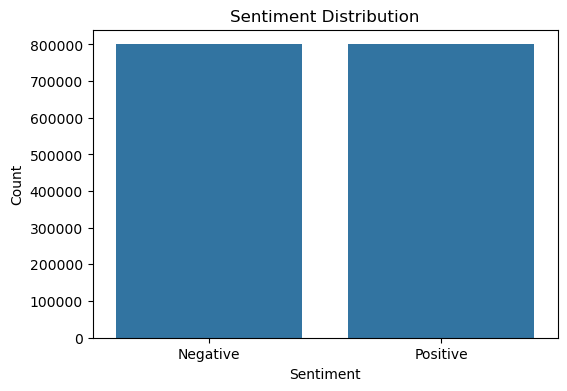

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="sentiment",
    data=df
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

Observation:

The dataset contains two sentiment classes:
- Positive
- Negative

The distribution is balanced, making it suitable for training a machine learning model.

In [11]:
percentage = df["sentiment"].value_counts(normalize=True) * 100

print(percentage)

sentiment
Negative    50.0
Positive    50.0
Name: proportion, dtype: float64


In [12]:
print(df["text"].head(10))

0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
5                        @Kwesidei not the whole crew 
6                                          Need a hug 
7    @LOLTrish hey  long time no see! Yes.. Rains a...
8                 @Tatiana_K nope they didn't have it 
9                            @twittera que me muera ? 
Name: text, dtype: str


In [13]:
df["Review_Length"] = df["text"].apply(len)

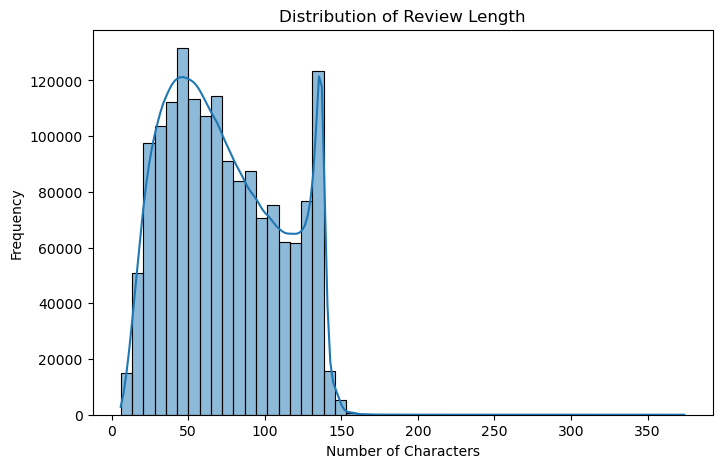

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Review_Length"],
    bins=50,
    kde=True
)

plt.title("Distribution of Review Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

Observation:

Most reviews are short text messages.

Only a small number of reviews are very long.

In [15]:
print("Average Review Length:", df["Review_Length"].mean())

Average Review Length: 74.09011125


In [16]:
!pip install nltk

In [17]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bhargav\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhargav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bhargav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Bhargav\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [19]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [20]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
df["Clean_Text"] = df["text"].apply(clean_text)

In [ ]:
df[["text","Clean_Text"]].head(10)

In [ ]:
df["Clean_Text"].isnull().sum()

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

In [ ]:
X = tfidf.fit_transform(df["Clean_Text"])

In [ ]:
df["Label"] = df["sentiment"].map({
    "Negative":0,
    "Positive":1
})

y = df["Label"]

In [ ]:
print(X.shape)

print(y.shape)

In [ ]:
print(tfidf.get_feature_names_out()[:30])

### TF-IDF Vectorizer

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features.

It assigns higher importance to words that appear frequently in a particular document but less frequently across the entire dataset.

Machine learning algorithms cannot understand text directly, so TF-IDF transforms text into numerical vectors suitable for training models.

In [ ]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

In [ ]:
df.to_csv("Cleaned_Sentiment_Data.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train,y_train)

In [ ]:
nb_prediction = nb_model.predict(X_test)

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train,y_train)

In [ ]:
lr_prediction = lr_model.predict(X_test)

In [ ]:
prediction_df = pd.DataFrame({

    "Actual":y_test.values,

    "Naive Bayes":nb_prediction,

    "Logistic Regression":lr_prediction

})

prediction_df.head(10)

In [ ]:
print("Naive Bayes Correct Predictions")

print((nb_prediction==y_test).sum())

In [ ]:
print("Logistic Regression Correct Predictions")

print((lr_prediction==y_test).sum())

In [ ]:
review = ["This mobile phone is amazing and I love it"]

review_vector = tfidf.transform(review)

prediction = lr_model.predict(review_vector)

print(prediction)

In [ ]:
if prediction[0]==1:

    print("Positive Review")

else:

    print("Negative Review")

In [ ]:
review = ["Worst product ever. Waste of money."]

In [ ]:
review_vector = tfidf.transform(review)

prediction = lr_model.predict(review_vector)

print(prediction)

In [ ]:
if prediction[0]==1:

    print("Positive Review")

else:

    print("Negative Review")

## Machine Learning Models

Two supervised machine learning models were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

The dataset was split into 80% training data and 20% testing data.

Both models were trained using TF-IDF features extracted from the cleaned review text.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from wordcloud import WordCloud

In [ ]:
print("Naive Bayes Accuracy")

print(accuracy_score(y_test, nb_prediction))

In [ ]:
print("Logistic Regression Accuracy")

print(accuracy_score(y_test, lr_prediction))

In [ ]:
print("Naive Bayes Precision")

print(precision_score(y_test, nb_prediction))

In [ ]:
print("Logistic Regression Precision")

print(precision_score(y_test, lr_prediction))

In [ ]:
print("Naive Bayes Recall")

print(recall_score(y_test, nb_prediction))

In [ ]:
print("Logistic Regression Recall")

print(recall_score(y_test, lr_prediction))

In [ ]:
print("Naive Bayes F1 Score")

print(f1_score(y_test, nb_prediction))

In [ ]:
print("Logistic Regression F1 Score")

print(f1_score(y_test, lr_prediction))

In [ ]:
print("Naive Bayes Report")

print(classification_report(y_test, nb_prediction))

In [ ]:
print("Logistic Regression Report")

print(classification_report(y_test, lr_prediction))

In [ ]:
cm = confusion_matrix(y_test, nb_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [ ]:
cm = confusion_matrix(y_test, lr_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
positive_text = " ".join(
    df[df["sentiment"]=="Positive"]["Clean_Text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews WordCloud")

plt.show()

In [ ]:
negative_text = " ".join(
    df[df["sentiment"]=="Negative"]["Clean_Text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews WordCloud")

plt.show()

In [ ]:
results = pd.DataFrame({

    "Review":df.loc[y_test.index,"text"],

    "Actual":y_test,

    "Predicted":lr_prediction

})

misclassified = results[
    results["Actual"] != results["Predicted"]
]

misclassified.head(5)

## Error Analysis

Some reviews are misclassified because:

- Presence of sarcasm
- Mixed emotions in one sentence
- Lack of context
- Slang words
- Short text messages

In [ ]:
comparison = pd.DataFrame({

    "Model":["Naive Bayes","Logistic Regression"],

    "Accuracy":[
        accuracy_score(y_test,nb_prediction),
        accuracy_score(y_test,lr_prediction)
    ],

    "Precision":[
        precision_score(y_test,nb_prediction),
        precision_score(y_test,lr_prediction)
    ],

    "Recall":[
        recall_score(y_test,nb_prediction),
        recall_score(y_test,lr_prediction)
    ],

    "F1 Score":[
        f1_score(y_test,nb_prediction),
        f1_score(y_test,lr_prediction)
    ]

})

comparison

## Conclusion

The sentiment analysis model successfully classified reviews into positive and negative sentiments.

Two machine learning algorithms were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

After comparing the evaluation metrics, Logistic Regression achieved the best overall performance.

This project demonstrates how Natural Language Processing (NLP) and Machine Learning can automatically analyze customer opinions.

Real-world applications include:

- Product Review Analysis
- Customer Feedback Monitoring
- Social Media Sentiment Analysis
- Brand Reputation Management
- Movie and Restaurant Review Analysis